# ImageNet Classification for the MLA100 NPU chip


## Generate coord plots using resnet

In [14]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import os
import torch.nn.functional as F
from tqdm import tqdm # Progress bar

# 1. Setup Teacher
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).to(device).eval()

# Hook to capture features from the last convolutional layer
visual_features = []
def hook_fn(module, input, output):
    visual_features.append(output)
# Register hook on the last bottleneck block of layer4
teacher.layer4[-1].register_forward_hook(hook_fn)

# Teacher Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_attention_map(img_path):
    global visual_features
    visual_features = [] # Reset buffer

    try:
        img = Image.open(img_path).convert('RGB')
        input_tensor = preprocess(img).unsqueeze(0).to(device)

        # Forward Pass
        output = teacher(input_tensor)

        # Get gradients for Grad-CAM
        score = output[:, output.argmax(dim=1)]
        teacher.zero_grad()
        score.backward()

        # visual_features[0] is the feature map from the hook (1, 2048, 7, 7)
        # We need gradients relative to this layer, but standard PyTorch hooks
        # make getting gradients tricky without full hooks.
        # SIMPLIFICATION: We will use "Activation-based Attention" (easier & stable)
        # Summing activations across channels is a robust proxy for saliency.

        fmap = visual_features[0].detach() # shape: [1, 2048, 7, 7]

        # Collapse channels using mean (spatial attention)
        heatmap = torch.mean(fmap, dim=1, keepdim=True) # [1, 1, 7, 7]

        # Resize to NPU Target Size (15x15)
        # We use bilinear interpolation to upscale the 7x7 teacher output
        heatmap = F.interpolate(heatmap, size=(15, 15), mode='bilinear', align_corners=False)

        # Normalize to [0, 1] per image
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        return heatmap.squeeze().cpu() # Returns [15, 15] tensor

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return torch.zeros(15, 15)

# 2. Process Dataset
IMAGE_ROOT = 'imagenet_train20a'
map_storage = {}
TRAIN_LIST = 'imagenet_train20.txt'

print("Generating 15x15 Teacher Maps...")
with open(TRAIN_LIST, 'r') as f:
    lines = f.readlines()

for line in tqdm(lines):
    filename = line.strip().split()[0]
    path_flat = os.path.join(IMAGE_ROOT, filename)
    path_nested = os.path.join(IMAGE_ROOT, filename.split('_')[0], filename)
    full_path = path_flat if os.path.exists(path_flat) else path_nested

    if os.path.exists(full_path):
        map_storage[filename] = get_attention_map(full_path)

# 3. Save as PyTorch object (Efficient storage)
torch.save(map_storage, 'teacher_maps_15x15.pt')
print(f"Saved {len(map_storage)} maps to teacher_maps_15x15.pt")

Generating 15x15 Teacher Maps...


100%|██████████| 6000/6000 [02:29<00:00, 40.12it/s]


Saved 6000 maps to teacher_maps_15x15.pt


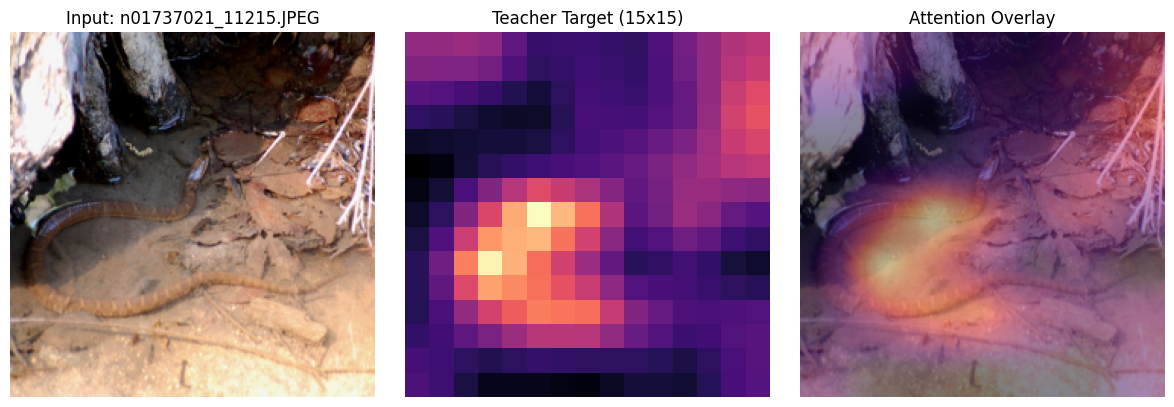

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_map(img_name, map_tensor):
    # Re-apply the nesting logic used in your Dataset class
    path_flat = os.path.join(IMAGE_ROOT, img_name)
    path_nested = os.path.join(IMAGE_ROOT, img_name.split('_')[0], img_name)
    full_path = path_flat if os.path.exists(path_flat) else path_nested

    if not os.path.exists(full_path):
        print(f"Error: Could not find image at {path_flat} or {path_nested}")
        return

    img = Image.open(full_path).convert("RGB").resize((240, 240))

    # Process Map
    heatmap = map_tensor.numpy()

    plt.figure(figsize=(12, 4))

    # 1. Original
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Input: {img_name}")
    plt.axis('off')

    # 2. 15x15 Map
    plt.subplot(1, 3, 2)
    # Using 'magma' or 'jet' helps highlight the saliency peaks
    plt.imshow(heatmap, cmap='magma')
    plt.title("Teacher Target (15x15)")
    plt.axis('off')

    # 3. Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    # Resize heatmap back to image size for the overlay
    heatmap_resized = np.array(Image.fromarray((heatmap*255).astype('uint8')).resize((240,240)))
    plt.imshow(heatmap_resized, alpha=0.5, cmap='magma')
    plt.title("Attention Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Test one - Pass the key (filename) directly
if len(map_storage) > 0:
    test_key = list(map_storage.keys())[16]
    visualize_map(test_key, map_storage[test_key])
else:
    print("map_storage is empty. Did the generation block run correctly?")

## Load Dataset

In [1]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.txt imagenet_train20.txt
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.txt imagenet_val20.txt

# Text contains:
# file class_number
# file2 class_number2
# ...

In [2]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.zip imagenet_train20.zip

In [3]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.zip imagenet_val20.zip

In [4]:
!unzip -o -q imagenet_train20.zip
#   inflating: imagenet_train20a/n04346328/n04346328_2302.JPEG
#  inflating: imagenet_train20a/n04346328/n04346328_2842.JPEG

In [5]:
!unzip -o -q imagenet_val20.zip
# NOT NESTED UNDER SUB FOLDERS LIKE TRAINING
# ex., we get
# /imagenet_val20/n01737021_10767.JPEG

## Install Requirements

In [6]:
!pip -q install onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 18.2 MB/s eta 0:00:00


In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.onnx
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import onnxscript
import onnxruntime as ort
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

## Prepare Dataset Loader

In [2]:
IMAGE_ROOT = 'imagenet_train20a'
TRAIN_LIST = 'imagenet_train20.txt'
VAL_IMAGE_ROOT = 'imagenet_val20'
VAL_LIST = 'imagenet_val20.txt'

# 48 T4
# 512 L4
BATCH_SIZE = 512

NUM_CLASSES = 20
INPUT_SHAPE = (240, 240)
NUM_EPOCHS = 10
LEARNING_RATE = 0.01

In [23]:
class ImageNet20Dataset(Dataset):
    def __init__(self, txt_file, root_dir, map_file=None, transform=None):
        self.img_labels = []
        self.root_dir = root_dir
        self.transform = transform

        # Load the map dictionary into RAM (it's small enough for 20k images)
        self.maps = torch.load(map_file) if map_file else {}

        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    self.img_labels.append((parts[0], int(parts[1])))

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        filename, label = self.img_labels[idx]

        # Path logic
        path_flat = os.path.join(self.root_dir, filename)
        path_nested = os.path.join(self.root_dir, filename.split('_')[0], filename)
        full_path = path_flat if os.path.exists(path_flat) else path_nested

        try:
            image = Image.open(full_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (240, 240))

        if self.transform:
            image = self.transform(image)

        # Retrieve map (Default to zeros if missing or validation)
        # Note: We unsqueeze(0) to make it [1, 15, 15] (Channel dim)
        target_map = self.maps.get(filename, torch.zeros(15, 15)).unsqueeze(0)

        return image, label, target_map

## Prepare Model

In [24]:
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16, pool_kernel=1):
        super(SEBlock, self).__init__()
        # Optimized: Using fixed AvgPool2d instead of Adaptive for NPU stability
        self.squeeze = nn.AvgPool2d(kernel_size=pool_kernel)
        self.excite = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        s = self.squeeze(x)
        e = self.excite(s)
        return x * e

class PConvBlock(nn.Module):
    def __init__(self, dim, n_div=4):
        super(PConvBlock, self).__init__()
        self.dim_conv3 = dim // n_div
        self.dim_untouched = dim - self.dim_conv3

        self.partial_conv = nn.Conv2d(self.dim_conv3, self.dim_conv3, 3, 1, 1, bias=False)
        self.bn = nn.BatchNorm2d(self.dim_conv3)
        self.relu = nn.ReLU(inplace=True)
        self.pw_conv = nn.Conv2d(dim, dim, 1, 1, 0, bias=False)
        self.bn_pw = nn.BatchNorm2d(dim)
        self.relu_pw = nn.ReLU(inplace=True)

    def forward(self, x):
        # Safer NPU slicing
        x1, x2 = torch.split(x, [self.dim_conv3, self.dim_untouched], dim=1)
        x1 = self.relu(self.bn(self.partial_conv(x1)))
        x = torch.cat((x1, x2), dim=1)
        return self.relu_pw(self.bn_pw(self.pw_conv(x)))

class NPUModel(nn.Module):
    def __init__(self, num_classes=20):
        super(NPUModel, self).__init__()

        # STAGE 1 & 2: Remain the same for early feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 256, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 64, 1, 1, 0, bias=False),
            nn.BatchNorm2d(64)
        )

        # STAGE 3: FasterNet Block
        self.stage3_down = nn.Sequential(
             nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
             nn.BatchNorm2d(128),
             nn.ReLU(inplace=True)
        )
        self.stage3_pconv = PConvBlock(dim=128)

        self.stage4_main = nn.Sequential(
            nn.Conv2d(128, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 7, stride=2, padding=3, groups=256, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SEBlock(256, pool_kernel=15),
            nn.Conv2d(256, 256, 1, bias=False),
            nn.BatchNorm2d(256)
        )
        self.stage4_shortcut = nn.Sequential(
            nn.Conv2d(128, 256, 1, stride=2, bias=False),
            nn.BatchNorm2d(256)
        )
        self.stage4_relu = nn.ReLU(inplace=True)

        # 1. Classification Head
        self.classifier_conv = nn.Conv2d(256, num_classes, 1)
        self.global_pool = nn.AvgPool2d(kernel_size=15)

        # 2. Map Regression Head (REPLACES Coord Head)
        # Input features are [B, 256, 15, 15]
        # We map 256 channels -> 1 channel
        self.map_head = nn.Sequential(
            nn.Conv2d(256, 1, kernel_size=1),
            nn.Sigmoid() # Force output to [0, 1] to match teacher
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3_pconv(self.stage3_down(x))
        identity = self.stage4_shortcut(x)
        x = self.stage4_main(x)
        features = self.stage4_relu(x + identity)
        # features shape is [Batch, 256, 15, 15]

        # Branch A: Class
        logits = self.global_pool(self.classifier_conv(features)).view(features.size(0), -1)

        # Branch B: Map
        # Output shape: [Batch, 1, 15, 15]
        saliency_map = self.map_head(features)

        return logits, saliency_map

## Data Augmentations

In [25]:
from torchvision.transforms import v2
cutmix = v2.CutMix(num_classes=20)

# alter the training dataset for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SHAPE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

# keep validation unaltered
transform_val = transforms.Compose([
    transforms.Resize(INPUT_SHAPE),
    transforms.ToTensor(),
])

train_dataset = ImageNet20Dataset(
    txt_file=TRAIN_LIST,
    root_dir=IMAGE_ROOT,
    map_file='teacher_maps_15x15.pt', # Pass the file we generated
    transform=train_transform
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f"Dataset loaded: {len(train_dataset)} images found.")


val_dataset = ImageNet20Dataset(txt_file=VAL_LIST, root_dir=VAL_IMAGE_ROOT, transform=transform_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Dataset loaded: {len(val_dataset)} images found.")

Dataset loaded: 6000 images found.
Dataset loaded: 1000 images found.


## Train Model

### Intialize model, criterion and optimizer

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = NPUModel().to(device)

# two criterion, one for class, one for coords
criterion_cls = nn.CrossEntropyLoss()
criterion_map = nn.MSELoss()

# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Weights for loss balancing
ALPHA = 1.0  # Classification weight
BETA = 10.0  # Map weight (maps are small values 0-1, so we boost the gradients)

Using device: cuda


### Start training loop

In [7]:
# Validation
# Tracks Accuracy and Top-5 Accuracy
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_acc = 100. * correct / total
    avg_loss = val_loss / len(val_loader)
    return avg_loss, avg_acc

In [8]:
class_names=[
    "Water snake",
    "Roseate spoonbill",
    "Night Heron",
    "Limpkin",
    "Godwit",
    "Dog",
    "Hyena",
    "Monarch Butterfly",
    "Ram",
    "Impala",
    "Accoustic Guitar",
    "Sink",
    "Cabinet",
    "Hair Brooch",
    "Xylophone",
    "Nail",
    "Piggy Bank",
    "Pillow",
    "Tractor",
    "Monuments",
    ]

In [31]:
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train = 0
    correct_train = 0
    total_loss = 0

    for i, (images, labels, target_maps) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        target_maps = target_maps.to(device).float() # [B, 1, 15, 15]

        optimizer.zero_grad()

        # Forward
        pred_logits, pred_maps = model(images)

        # Loss Calculation
        loss_c = criterion_cls(pred_logits, labels)
        loss_m = criterion_map(pred_maps, target_maps)

        loss = (ALPHA * loss_c) + (BETA * loss_m)

        loss.backward()
        optimizer.step()

        # Metrics
        _, predicted = pred_logits.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        total_loss += loss.item()

        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}] Step [{i+1}] | Acc: {100.*correct_train/total_train:.1f}% | Map Loss: {loss_m.item():.4f}")

    # --- VALIDATION PHASE ---
    model.eval()
    val_correct = 0
    val_total = 0
    val_map_loss = 0.0

    with torch.no_grad():
        for images, labels, target_maps in val_loader:
            images, labels = images.to(device), labels.to(device)
            target_maps = target_maps.to(device).float()

            # Forward pass
            pred_logits, pred_maps = model(images)

            # Validation Metrics
            # Note: We still calculate map loss if target_maps were provided for Val
            loss_m = criterion_map(pred_maps, target_maps)
            val_map_loss += loss_m.item()

            _, predicted = pred_logits.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    avg_val_acc = 100. * val_correct / val_total
    avg_val_map_loss = val_map_loss / len(val_loader)

    print(f"\n>> EPOCH {epoch+1} SUMMARY <<")
    print(f"Val Acc: {avg_val_acc:.2f}% | Val Map MSE: {avg_val_map_loss:.6f}")
    print("-" * 30)

Epoch [1] Step [10] | Acc: 54.6% | Map Loss: 0.0350

>> EPOCH 1 SUMMARY <<
Val Acc: 41.80% | Val Map MSE: 0.070615
------------------------------
Epoch [2] Step [10] | Acc: 56.4% | Map Loss: 0.0346

>> EPOCH 2 SUMMARY <<
Val Acc: 35.90% | Val Map MSE: 0.074210
------------------------------
Epoch [3] Step [10] | Acc: 58.0% | Map Loss: 0.0363

>> EPOCH 3 SUMMARY <<
Val Acc: 43.70% | Val Map MSE: 0.061272
------------------------------
Epoch [4] Step [10] | Acc: 59.2% | Map Loss: 0.0354

>> EPOCH 4 SUMMARY <<
Val Acc: 46.80% | Val Map MSE: 0.076539
------------------------------
Epoch [5] Step [10] | Acc: 60.3% | Map Loss: 0.0352

>> EPOCH 5 SUMMARY <<
Val Acc: 45.40% | Val Map MSE: 0.079257
------------------------------
Epoch [6] Step [10] | Acc: 61.6% | Map Loss: 0.0348

>> EPOCH 6 SUMMARY <<
Val Acc: 43.40% | Val Map MSE: 0.057829
------------------------------
Epoch [7] Step [10] | Acc: 63.7% | Map Loss: 0.0352

>> EPOCH 7 SUMMARY <<
Val Acc: 51.30% | Val Map MSE: 0.090219
---------

KeyboardInterrupt: 

## Export Model to ONNX

In [ ]:
model.eval()

# Move dummy input to same device as model
dummy_input = torch.randn(1, 3, 240, 240).to(device)
onnx_filename = "model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    verbose=False,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"Model successfully exported to {onnx_filename}")

/tmp/ipython-input-2075491432.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0213 21:31:52.555000 790 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0213 21:31:52.556000 790 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0213 21:31:52.558000 790 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). 

Model successfully exported to model.onnx
